# GANrec Step-Through on a Shepp3D Phantom with a Missing Wedge

This notebook walks through how the `ganrec` GAN-based tomographic reconstructor works by exposing each of its moving parts on the same phantom we use elsewhere in this project (the `tomopy.shepp3d` cube with a limited tilt range).

The sections are:

1. **Setup** — imports + top-of-notebook config.
2. **Phantom + projections** — build the simulated object and missing-wedge sinogram.
3. **Baseline gridrec reconstruction** — show the missing-wedge artifact.
4. **GANrec component walkthrough** — Generator, Radon, Discriminator, losses, and an unrolled training loop.
5. **Full `GANtomo(...).recon()` call** — the canonical one-liner.
6. **Side-by-side comparison** — ground truth vs gridrec vs ganrec, with RMSE / SSIM metrics.
7. **(Optional) Full 3D ganrec volume** — loop ganrec over all slices. SLOW.

## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import optim
import tomopy
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Project utilities
from tomoDataClass import tomoData, simulate_projections
from helperFunctions import MoviePlotter

# GANrec components
from ganrectorch.ganrec import GANtomo, generator_loss, discriminator_loss
from ganrectorch.propagators import RadonTransform
from ganrectorch.models import Generator, Discriminator
from ganrectorch.utils import tensor_to_np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch imported successfully.
SVMBIR imported successfully.
Torch device: cuda
GPU: Tesla T4


In [3]:
# Configuration — change ITER_NUM to trade run time vs reconstruction quality.
ITER_NUM   = 1000          # GAN iterations per slice (canonical ganrec default)
IMAGE_SIZE = 128           # cube side length of the shepp3d phantom
N_ANGLES   = 128           # number of projection angles in the tilt series
ANG_LOW    = -71.99        # min tilt (deg)  → matches test_notebook_phanton.ipynb
ANG_HIGH   =  58.80        # max tilt (deg)  → ~131° span, leaving a ~49° missing wedge
SLICE_IDX  = IMAGE_SIZE // 2  # central Z slice for the 2-D walkthrough
RNG_SEED   = 0

# Note: test_notebook_phanton.ipynb uses N_ANGLES=100, but ganrec's Discriminator has
# four stride-2 convs without padding, so each spatial dim shrinks by ~16× before
# flattening. Below ~110 angles the height collapses to 0 and the conv stack fails.
# We bump to 128 here — the missing-wedge geometry (angle range) is unchanged.

## 2. Build the phantom + missing-wedge projections

We replicate the phantom and tilt geometry from [test_notebook_phanton.ipynb](test_notebook_phanton.ipynb). The angle range spans only `-71.99°` → `58.80°` (≈131°), so **the projections cover only part of the 180° half-rotation** — that's our missing wedge. We do **not** apply the 30-pixel zero pad from the original notebook (it exists to absorb alignment shifts, which we don't have here), so projections and reconstructions stay at the phantom's native 128 × 128.

In [4]:
# Phantom
obj = tomopy.shepp3d(size=IMAGE_SIZE).astype(np.float32)
print('Phantom shape:', obj.shape)

# Tilt angles (degrees) — implicit missing wedge from the limited range
angles_deg = tomopy.angles(nang=N_ANGLES, ang1=ANG_LOW, ang2=ANG_HIGH).astype(np.float32)

# Forward project the phantom
projections = simulate_projections(obj, angles_deg, pad=False, use_astra=False).astype(np.float32)
print('Projections shape (n_angles, height, width):', projections.shape)

# Centre the angle array around 0 for a symmetric tilt series (this is what gridrec expects)
angles_deg = angles_deg - np.mean(angles_deg)
print(f'Angle span: [{angles_deg.min():.2f}, {angles_deg.max():.2f}] deg  '
      f'({angles_deg.max() - angles_deg.min():.2f}° covered, '
      f'{180 - (angles_deg.max() - angles_deg.min()):.2f}° missing wedge)')

Phantom shape: (128, 128, 128)
Projections shape (n_angles, height, width): (128, 128, 128)
Angle span: [-1.14, 1.14] deg  (2.28° covered, 177.72° missing wedge)


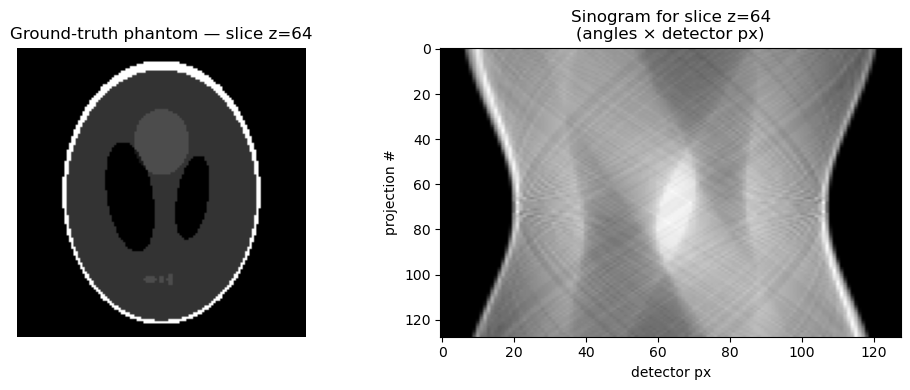

In [5]:
# Inspect a phantom slice and its sinogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(obj[SLICE_IDX], cmap='gray')
axes[0].set_title(f'Ground-truth phantom — slice z={SLICE_IDX}')
axes[0].axis('off')
axes[1].imshow(projections[:, SLICE_IDX, :], cmap='gray', aspect='auto')
axes[1].set_title(f'Sinogram for slice z={SLICE_IDX}\n(angles × detector px)')
axes[1].set_xlabel('detector px')
axes[1].set_ylabel('projection #')
plt.tight_layout(); plt.show()

## 3. Baseline reconstruction — tomopy gridrec (FBP)

Filtered back-projection on a limited tilt range produces the classic **missing-wedge elongation**: structures stretch along the unsampled direction. This is the artifact ganrec needs to reduce.



Using CPU-based reconstruction. Algorithm:  gridrec
Reconstruction completed.
gridrec volume shape: (128, 128, 128)


Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)Error.  nthreads must be a positive integer

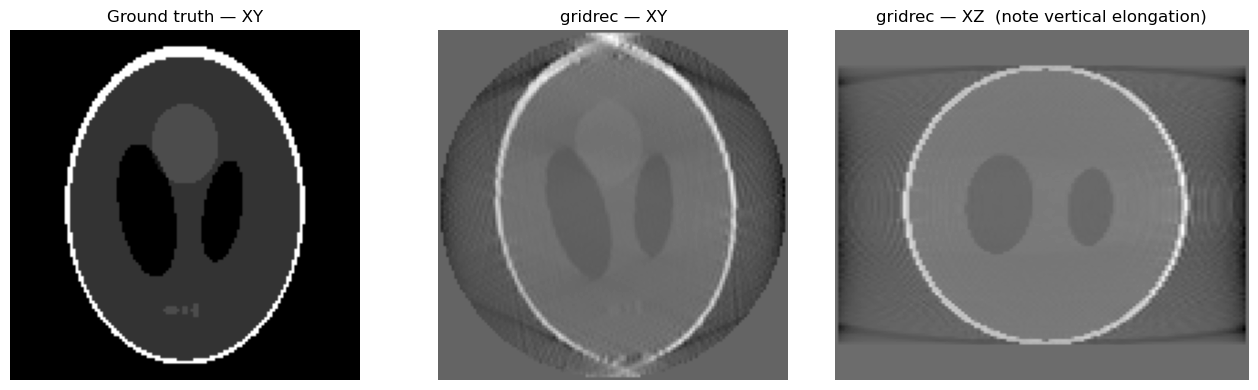

In [6]:
tomo = tomoData(projections, angles_deg)
tomo.reconstruct(algorithm='gridrec')
gridrec_vol = tomo.recon
print('gridrec volume shape:', gridrec_vol.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(obj[SLICE_IDX], cmap='gray')
axes[0].set_title('Ground truth — XY')
axes[1].imshow(gridrec_vol[SLICE_IDX], cmap='gray')
axes[1].set_title('gridrec — XY')
axes[2].imshow(gridrec_vol[:, IMAGE_SIZE // 2, :], cmap='gray', aspect='auto')
axes[2].set_title('gridrec — XZ  (note vertical elongation)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Walk through GANrec, component by component

GANrec is a *generative* approach: a Generator network proposes a candidate reconstruction, a differentiable Radon operator forward-projects that candidate, and a Discriminator + L1 loss judge whether the resulting sinogram matches the measured one. We pick a single 2-D slice and step through each piece.

GANtomo expects:
- `prj_input`: 2-D numpy array of shape `(n_angles, width)` — i.e. one sinogram.
- `angle`: 1-D numpy array of angles **in radians**.

Internally everything is reshaped to `(batch=1, channel=1, n_angles, width)`.

In [7]:
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Pick one slice + convert angles to radians (the convention used by ganrec's RadonTransform)
prj_slice = projections[:, SLICE_IDX, :].astype(np.float32)              # (n_angles, width)
angles_rad = (angles_deg.astype(np.float32) * np.pi / 180.0)             # radians
n_ang, px = prj_slice.shape
print('Slice sinogram shape:', prj_slice.shape, '  angles range (rad):',
      f'[{angles_rad.min():.3f}, {angles_rad.max():.3f}]')

Slice sinogram shape: (128, 128)   angles range (rad): [-0.020, 0.020]


### 4a. Normalize and move to GPU

Ganrec normalises projections to roughly `[0, 1]` (z-score then shift to start at zero). The forward call below mirrors what `GANtomo._input_data` + `GANtomo.nor_tomo` do internally.

In [8]:
def torch_nor_tomo(x):
    """z-score, then shift so the minimum is 0  (same recipe as GANtomo.nor_tomo)."""
    x = (x - x.mean()) / x.std()
    return x - x.min()

prj_t = torch.from_numpy(prj_slice).view(1, 1, n_ang, px).to(DEVICE)
prj_t = torch_nor_tomo(prj_t)
ang_t = torch.from_numpy(angles_rad).to(DEVICE)
print('Normalised projection tensor: shape', tuple(prj_t.shape),
      f' min={prj_t.min().item():.3f}  max={prj_t.max().item():.3f}  mean={prj_t.mean().item():.3f}')

RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


### 4b. The Generator

The Generator maps a sinogram to a reconstruction. Architecture (see [ganrec/ganrectorch/models.py:53-102](ganrec/ganrectorch/models.py)):

```
(1, 1, n_angles, width)
    → Flatten  → Dense×4 (128, 128, 128, width²)
    → reshape (1, 1, width, width)
    → Conv ×3  → ConvTranspose ×3  → Conv (1×1×3×3)
    → (1, 1, width, width)   ← candidate reconstruction
```

All dense layers use LayerNorm + LeakyReLU + Dropout. We run a single forward pass on the *untrained* generator so the reader can see how noisy the initial guess is.

In [ ]:
generator = Generator(img_h=n_ang, img_w=px, conv_num=32, conv_size=3, dropout=0.25, output_num=1).to(DEVICE)

n_params = sum(p.numel() for p in generator.parameters())
print(f'Generator parameter count: {n_params:,}')

with torch.no_grad():
    init_recon = generator(prj_t)         # (1, 1, px, px)
    init_recon_n = torch_nor_tomo(init_recon)
print('Initial reconstruction tensor shape:', tuple(init_recon.shape))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(init_recon[0, 0].cpu().numpy(), cmap='gray');     ax[0].set_title('Generator output (untrained)')
ax[1].imshow(init_recon_n[0, 0].cpu().numpy(), cmap='gray');   ax[1].set_title('…after nor_tomo')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

### 4c. The Radon forward operator

`RadonTransform` ([ganrec/ganrectorch/propagators.py:8-47](ganrec/ganrectorch/propagators.py)) implements the forward projection in pure PyTorch:

1. Build a stack of 2D rotation matrices from the angle array.
2. Use `F.affine_grid` + `F.grid_sample` to rotate the candidate image by each angle.
3. Sum along the projection direction.

The whole thing is differentiable end-to-end, so gradients of the L1 reconstruction loss flow back through it into the Generator weights. No ASTRA or external library — just `torch.nn.functional`.

In [ ]:
radon = RadonTransform(torch.empty(1, 1, px, px, device=DEVICE), ang_t).to(DEVICE)

with torch.no_grad():
    prj_rec = radon(init_recon_n, ang_t)         # forward-project the initial recon
    prj_rec = torch_nor_tomo(prj_rec)
print('Reprojected sinogram shape:', tuple(prj_rec.shape))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(prj_t[0, 0].cpu().numpy(),    cmap='gray', aspect='auto'); ax[0].set_title('Measured sinogram')
ax[1].imshow(prj_rec[0, 0].cpu().numpy(),  cmap='gray', aspect='auto'); ax[1].set_title('Re-projected (untrained generator)')
ax[2].imshow(torch.abs(prj_t - prj_rec)[0, 0].cpu().numpy(), cmap='magma', aspect='auto')
ax[2].set_title('|measured − reprojected|\n(this is what L1 loss minimises)')
for a in ax: a.set_xlabel('detector px')
plt.tight_layout(); plt.show()

### 4d. The Discriminator

The Discriminator ([ganrec/ganrectorch/models.py:137-173](ganrec/ganrectorch/models.py)) sees a sinogram and outputs a length-256 logit vector that's pushed toward 1 for real sinograms and toward 0 for re-projected ones (via `BCEWithLogitsLoss`). Untrained, both outputs are near zero.

In [ ]:
discriminator = Discriminator().to(DEVICE)

with torch.no_grad():
    real_out = discriminator(prj_t)
    fake_out = discriminator(prj_rec)
n_d_params = sum(p.numel() for p in discriminator.parameters())
print(f'Discriminator parameter count: {n_d_params:,}')
print(f'Discriminator output shape (per sinogram): {tuple(real_out.shape)}')
print(f'Mean logit  — real sinogram: {real_out.mean().item():+.4f}'
      f'   reprojected: {fake_out.mean().item():+.4f}')

### 4e. Losses

From [ganrec/ganrectorch/ganrec.py:37-59](ganrec/ganrectorch/ganrec.py):

- **Generator loss** = `BCEWithLogits(fake_out, 1) + l1_ratio · ‖prj − prj_rec‖₁`. With `l1_ratio=100`, this is dominated by the pixel-wise L1 between the measured and reprojected sinograms — the adversarial term is a regulariser that nudges the generator toward outputs whose reprojections *look* like real sinograms.
- **Discriminator loss** = `BCE(real_out, 1) + BCE(fake_out, 0)` — standard GAN discriminator objective.

In [ ]:
L1_RATIO = 100
g_loss0 = generator_loss(fake_out, prj_t, prj_rec, L1_RATIO)
d_loss0 = discriminator_loss(real_out, fake_out)
print(f'Initial generator loss     : {g_loss0.item():.4f}')
print(f'Initial discriminator loss : {d_loss0.item():.4f}')

### 4f. Unrolled training loop

Now we run the loop by hand for a small number of iterations so the dynamics are visible. Compare this to `GANtomo.recon_step` ([ganrec/ganrectorch/ganrec.py:143-168](ganrec/ganrectorch/ganrec.py)) — same logic, with `autocast`/`GradScaler` stripped out for clarity.

Per iteration:

1. Generator: `sinogram → reconstruction guess`
2. Radon: `reconstruction guess → reprojected sinogram`
3. Discriminator: score real and reprojected sinograms
4. Compute the two losses
5. Backprop generator loss and discriminator loss; step their Adam optimizers

In [ ]:
MANUAL_ITERS = 200
SNAPSHOT_EVERY = 40

# Fresh networks so we start from random init
torch.manual_seed(RNG_SEED)
gen  = Generator(img_h=n_ang, img_w=px, conv_num=32, conv_size=3, dropout=0.25, output_num=1).to(DEVICE)
disc = Discriminator().to(DEVICE)
g_opt = optim.Adam(gen.parameters(),  lr=1e-3)
d_opt = optim.Adam(disc.parameters(), lr=1e-3)
radon_manual = RadonTransform(torch.empty(1, 1, px, px, device=DEVICE), ang_t).to(DEVICE)

g_hist, d_hist, snapshots = [], [], []

for it in range(MANUAL_ITERS):
    g_opt.zero_grad(); d_opt.zero_grad()

    recon  = torch_nor_tomo(gen(prj_t))
    rep    = torch_nor_tomo(radon_manual(recon, ang_t))
    r_out  = disc(prj_t)
    f_out  = disc(rep)
    g_loss = generator_loss(f_out, prj_t, rep, L1_RATIO)
    d_loss = discriminator_loss(r_out, f_out)

    g_loss.backward(retain_graph=True)
    d_loss.backward()
    g_opt.step(); d_opt.step()

    g_hist.append(g_loss.item()); d_hist.append(d_loss.item())
    if it % SNAPSHOT_EVERY == 0 or it == MANUAL_ITERS - 1:
        snapshots.append((it, recon[0, 0].detach().cpu().numpy()))

print(f'Done — final g_loss={g_hist[-1]:.3f}  d_loss={d_hist[-1]:.3f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(g_hist, label='Generator');     axes[0].set_xlabel('iteration'); axes[0].set_title('Generator loss')
axes[1].plot(d_hist, label='Discriminator', color='C1'); axes[1].set_xlabel('iteration'); axes[1].set_title('Discriminator loss')
for a in axes: a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

n = len(snapshots)
fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.6))
for ax, (it, img) in zip(np.atleast_1d(axes), snapshots):
    ax.imshow(img, cmap='gray'); ax.set_title(f'iter {it}'); ax.axis('off')
plt.suptitle(f'Reconstruction progress (manual loop, {MANUAL_ITERS} iters)')
plt.tight_layout(); plt.show()

200 iterations is short — the manual loop above is for illustration only. The full call in the next section uses `ITER_NUM` iterations (default 1000) plus mixed-precision (`autocast`/`GradScaler`) for the real reconstruction.

## 5. Run the full `GANtomo` API

This is the one-liner that production users would call. `recon_monitor=False` disables the live matplotlib display (`RECONmonitor`) so the cell runs cleanly headless.

In [ ]:
torch.manual_seed(RNG_SEED)
ganrec_slice = GANtomo(prj_slice, angles_rad, iter_num=ITER_NUM, recon_monitor=False).recon()
print('GANtomo output shape:', np.shape(ganrec_slice))
# tensor_to_np reduces a (1, 1, px, px) tensor to (px, px); be defensive in case that changes.
ganrec_slice = np.asarray(ganrec_slice)
while ganrec_slice.ndim > 2:
    ganrec_slice = ganrec_slice[0]
print('Reduced to 2-D reconstruction:', ganrec_slice.shape)

## 6. Compare ground truth · gridrec · ganrec

Ganrec normalises projections internally, so its reconstruction lives on a different intensity scale than the gridrec output and the phantom. We match scales (z-score) before computing RMSE/SSIM so the comparison is fair.

In [ ]:
def zscore(x):
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)

gt        = obj[SLICE_IDX]
gridrec_s = gridrec_vol[SLICE_IDX]

gt_n, gr_n, gn_n = zscore(gt), zscore(gridrec_s), zscore(ganrec_slice)

rmse_gr = float(np.sqrt(np.mean((gt_n - gr_n) ** 2)))
rmse_gn = float(np.sqrt(np.mean((gt_n - gn_n) ** 2)))
data_range = float(gt_n.max() - gt_n.min())
ssim_gr = float(ssim(gt_n, gr_n, data_range=data_range))
ssim_gn = float(ssim(gt_n, gn_n, data_range=data_range))

print(f"{'Method':<10}  {'RMSE ↓':>10}  {'SSIM ↑':>10}")
print(f"{'-'*34}")
print(f"{'gridrec':<10}  {rmse_gr:>10.4f}  {ssim_gr:>10.4f}")
print(f"{'ganrec':<10}  {rmse_gn:>10.4f}  {ssim_gn:>10.4f}")

vmin, vmax = np.percentile(gt_n, [2, 98])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, img) in zip(axes, [('Ground truth', gt_n), ('gridrec', gr_n), ('ganrec', gn_n)]):
    ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.axis('off')
plt.suptitle(f'Slice z={SLICE_IDX}  (z-score normalised for visualisation)')
plt.tight_layout(); plt.show()

**What to look for:**
- *gridrec* shows streaks and a clear vertical "smear" — the missing wedge gets imprinted on every feature.
- *ganrec* should look closer to the ground truth phantom; the generator's implicit prior fills in the missing-wedge information that gridrec cannot recover analytically.
- The RMSE should be lower and the SSIM higher for ganrec. If they're not, try increasing `ITER_NUM` (e.g. 2000) — ganrec is iterative and benefits from more steps.

## 7. (Optional) Full 3-D ganrec reconstruction

GANtomo is 2-D, so a full volume means looping over every Z slice. With `ITER_NUM=1000` and 128 slices on one GPU, this typically takes **~1–4 hours** depending on hardware. Skip on the first run; come back when you've confirmed everything above looks right.

If you do run it, the cell below stacks the per-slice results into a `(IMAGE_SIZE, IMAGE_SIZE, IMAGE_SIZE)` volume that can be compared to `gridrec_vol` and `obj` directly.

In [ ]:
# ⚠ SLOW — uncomment the loop below to run the full 3-D ganrec reconstruction.
#
# from tqdm.notebook import tqdm as tqdm_nb
#
# ganrec_vol = np.zeros_like(obj, dtype=np.float32)
# for z in tqdm_nb(range(obj.shape[0]), desc='ganrec slices'):
#     sino = projections[:, z, :].astype(np.float32)
#     out = GANtomo(sino, angles_rad, iter_num=ITER_NUM, recon_monitor=False).recon()
#     out = np.asarray(out)
#     while out.ndim > 2:
#         out = out[0]
#     ganrec_vol[z] = out
#
# print('Full ganrec volume shape:', ganrec_vol.shape)
# MoviePlotter(ganrec_vol)